# 6. Preprocesamiento, validación y línea base

## 6.1. Objetivo del capítulo

Este capítulo construye la infraestructura sobre la que corren las 112 combinaciones del experimento de clasificación (siete modelos, cuatro estrategias de balanceo y cuatro optimizadores) y establece el punto de referencia contra el que se medirán. Productos concretos:

1. Un **preprocesador encapsulado** que se ajusta dentro de cada fold, de modo que ninguna estimación (medianas, modas, niveles de categorías) use información del conjunto de evaluación.
2. Un **esquema de validación cruzada anidada y agrupada por paciente**, con el bucle interno para seleccionar hiperparámetros y el externo para estimar desempeño.
3. Una **línea base** con regresión logística, que fija la expectativa realista de desempeño y sirve de referencia para juzgar si la complejidad añadida de los modelos posteriores se traduce en mejora.
4. Los **espacios de búsqueda** de los cuatro optimizadores, diseñados para que la comparación entre ellos sea a igual presupuesto.
5. El **análisis de optimización computacional** que exige la guía: complejidad teórica frente a tiempo medido, comparación entre la versión estándar y la optimizada de cada modelo, paralelización y perfilamiento. Del resultado se deriva el presupuesto del experimento completo.

El código de este motor (preprocesador, fábricas de modelos, optimizadores y el ejecutor con validación anidada) vive en `experimento.py` y no en este notebook. La razón es la misma que llevó las utilidades del capítulo 1 a `config.py`: los capítulos 6 a 9 comparten esta infraestructura, y duplicarla en cada uno arriesgaría que una corrección se aplique en un notebook y se olvide en otro.

In [1]:
from config import *

import experimento as ex

train = leer_tabla("diabetes_train")
roles = roles_variables()

OBJETIVO = roles["objetivo"]
IDENTIFICADOR = roles["identificador"]
PREDICTORES = (roles["numericas"] + roles["ordinales"]
               + roles["binarias"] + roles["categoricas"])

X = train[PREDICTORES]
y = train[OBJETIVO]
grupos = train[IDENTIFICADOR]

print(f"Entrenamiento : {len(X):,} encuentros de {grupos.nunique():,} pacientes")
print(f"Predictores   : {len(PREDICTORES)}")
print(f"Clase positiva: {y.mean():.2%}")

Entrenamiento : 79,473 encuentros de 56,036 pacientes
Predictores   : 38
Clase positiva: 11.39%


## 6.2. El preprocesador

### 6.2.1. Por qué va dentro del pipeline

La imputación, el escalado y la codificación son **transformaciones con parámetros estimados**: una mediana, un rango intercuartílico, una moda, el conjunto de niveles observados de cada categórica. Si esos parámetros se calculan sobre todo el conjunto y luego se parte en folds, cada fold de validación habrá contribuido a definir la transformación con la que se le evalúa. El resultado es una estimación optimista del desempeño, y el efecto crece con la agresividad de la transformación: es leve en un escalado y severo en un remuestreo sintético como SMOTE, donde las muestras generadas pueden interpolar entre un punto de entrenamiento y otro de validación.

La solución no es un orden cuidadoso de las celdas, sino estructural: todo el preprocesamiento se declara como etapas de un `Pipeline`, y el pipeline completo se pasa al validador cruzado. Así el ajuste ocurre por construcción dentro de cada fold y no depende de que nadie se equivoque al escribir el código.

### 6.2.2. Tratamiento por bloque de variables

| Bloque | Transformación | Justificación |
|---|---|---|
| Numéricas y ordinales | Imputación por mediana y escalado robusto | El capítulo 3 rechazó la normalidad en todas y documentó atípicos clínicamente plausibles que no se recortan. Con colas pesadas, la media y la desviación estándar quedan desplazadas, mientras que la mediana y el rango intercuartílico no. La imputación actúa solo como salvaguarda: el conjunto no tiene faltantes |
| Binarias | Ninguna | Ya están en `{0, 1}`; escalarlas no aporta y dificulta interpretar los coeficientes |
| Categóricas | Imputación por moda y codificación one-hot con agrupación de niveles poco frecuentes, salvo `race`, que se codifica sin agrupar | La codificación one-hot no impone orden entre categorías nominales. El umbral de frecuencia evita que un nivel presente en el fold de entrenamiento y ausente en el de validación genere una columna constante, que desestabiliza los coeficientes de los modelos lineales entre folds. `race` queda fuera del umbral por la misma razón que en el capítulo 2: el grupo `Asian` debe conservarse desagregado para el análisis de equidad |

El escalado es indispensable para los modelos basados en distancias o en márgenes (k-NN, SVM) y para los lineales regularizados, donde la penalización es sensible a la escala de cada coeficiente. Los ensambles de árboles son invariantes a transformaciones monótonas, así que para ellos es inocuo: se aplica de todas formas para que todas las combinaciones compartan el mismo preprocesador y las diferencias observadas se atribuyan al modelo y no al preprocesamiento.

In [2]:
preprocesador = ex.construir_preprocesador(roles)
preprocesador

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer

In [3]:
# Ajuste ilustrativo sobre el conjunto completo de entrenamiento, únicamente
# para inspeccionar la dimensión resultante. En el experimento este ajuste
# ocurre dentro de cada fold.
matriz = preprocesador.fit_transform(X)
variables = ex.nombres_variables(preprocesador)

print(f"Dimensión de la matriz: {matriz.shape[0]:,} x {matriz.shape[1]}")
print(f"Tipo de matriz        : {type(matriz).__name__}")
print(f"Densidad              : {matriz.nnz / (matriz.shape[0] * matriz.shape[1]):.1%}")
print(f"\nPrimeras 12 variables: {variables[:12]}")

Dimensión de la matriz: 79,473 x 152
Tipo de matriz        : csr_matrix
Densidad              : 22.2%

Primeras 12 variables: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'n_farmacos_activos', 'age_ord', 'hospitalizacion_previa', 'race_AfricanAmerican']


Los 38 predictores originales se convierten en 152 columnas. La matriz resultante es dispersa, con alrededor del 22 % de entradas no nulas, consecuencia de la codificación one-hot: cada variable categórica aporta tantas columnas como niveles, de las cuales solo una vale 1 en cada fila.

Parte de esas columnas llevan el sufijo `infrequent_sklearn`. Son los niveles que, pese a la agrupación del capítulo 2, quedan por debajo del 1 % dentro del conjunto de entrenamiento, como la categoría `"Otro"` del tipo de admisión. El codificador los reúne en una columna por variable, de modo que ninguna columna queda casi vacía.

La representación depende del modelo. La matriz dispersa ahorra memoria y acelera los modelos lineales (logística y SVM), cuyos solvers recorren solo las entradas no nulas. Naive Bayes, el árbol, Random Forest y k-NN reciben en cambio la matriz densa: `GaussianNB` no admite matrices dispersas, y las rutas dispersas de los árboles y de k-NN en scikit-learn son un orden de magnitud más lentas que las densas. La sección 6.7 mide esa diferencia.

## 6.3. El esquema de validación

### 6.3.1. Por qué agrupada

El capítulo 2 adoptó como población de estudio todos los encuentros, de modo que un paciente puede aportar varias filas. Una partición por filas reparte esas filas entre entrenamiento y validación, y el modelo puede reconocer al paciente en lugar de aprender el mecanismo clínico.

La magnitud del problema se puede medir, y conviene hacerlo en lugar de asumirla.

In [4]:
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold

por_filas = StratifiedKFold(n_splits=5, shuffle=True,
                            random_state=RANDOM_STATE)
indices_train, indices_val = next(por_filas.split(X, y))
compartidos = len(set(grupos.iloc[indices_train])
                  & set(grupos.iloc[indices_val]))

print("Con partición por filas (StratifiedKFold):")
print(f"  pacientes en validación          : "
      f"{grupos.iloc[indices_val].nunique():,}")
print(f"  de ellos, presentes en entrenamiento: {compartidos:,} "
      f"({100 * compartidos / grupos.iloc[indices_val].nunique():.1f} %)")

Con partición por filas (StratifiedKFold):
  pacientes en validación          : 14,359
  de ellos, presentes en entrenamiento: 5,467 (38.1 %)


El 38 % de los pacientes del fold de validación también aparece en el de entrenamiento. Queda por ver cuánto infla eso las métricas, que es la pregunta que realmente importa.

In [5]:
from sklearn.model_selection import cross_validate

pipeline_base = ex.construir_pipeline("logistica", "class_weight", roles)

esquemas = {
    "Por filas (StratifiedKFold)": (
        StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        None),
    "Por paciente (StratifiedGroupKFold)": (
        StratifiedGroupKFold(n_splits=5, shuffle=True,
                             random_state=RANDOM_STATE),
        grupos),
}

filas = []
for nombre, (cv, agrupacion) in esquemas.items():
    # cross_validate calcula las dos métricas con los mismos ajustes, en lugar
    # de repetir la validación cruzada una vez por métrica.
    puntajes = cross_validate(pipeline_base, X, y, groups=agrupacion, cv=cv,
                              scoring=["roc_auc", "average_precision"],
                              n_jobs=-1)
    auc, ap = puntajes["test_roc_auc"], puntajes["test_average_precision"]
    filas.append({
        "esquema": nombre,
        "AUC-ROC media": auc.mean(), "AUC-ROC sd": auc.std(ddof=1),
        "AUC-PR media": ap.mean(), "AUC-PR sd": ap.std(ddof=1),
    })

comparacion_cv = pd.DataFrame(filas).set_index("esquema").round(4)
comparacion_cv

,AUC-ROC media,AUC-ROC sd,AUC-PR media,AUC-PR sd
esquema,,,,
Por filas (StratifiedKFold),0.6616,0.0071,0.2103,0.0015
Por paciente (StratifiedGroupKFold),0.6622,0.0069,0.2095,0.0112


El resultado es instructivo y merece registrarse con precisión: **para la regresión logística el efecto es prácticamente nulo**. Las dos estimaciones difieren en menos de 0.001 tanto en AUC-ROC como en AUC-PR, pese a que el 38 % de los pacientes de validación aparecía también en entrenamiento.

La explicación es la capacidad del modelo. Una regresión logística con 152 coeficientes no puede memorizar pacientes individuales: ajusta una superficie de decisión global, y ver dos veces a la misma persona apenas la desplaza. El riesgo de la partición por filas no está en los modelos lineales, sino en los de alta capacidad, que sí pueden aprender identidades.

Hay una segunda diferencia, menos visible y también relevante. La desviación estándar del AUC-PR entre folds es varias veces mayor con la partición agrupada. Al repartir los encuentros de un mismo paciente entre folds, la partición por filas hace que los folds se parezcan artificialmente entre sí y subestima la incertidumbre de la estimación.

Eso se comprueba con dos modelos de mayor capacidad sobre una submuestra, para que el cálculo sea viable.

In [6]:
# Submuestra de pacientes: k-NN y Random Forest son costosos y aquí solo se
# necesita contrastar los dos esquemas de validación entre sí.
pacientes_muestra = (grupos.drop_duplicates()
                           .sample(12_000, random_state=RANDOM_STATE))
submuestra = train[train[IDENTIFICADOR].isin(pacientes_muestra)]
X_sub = submuestra[PREDICTORES]
y_sub = submuestra[OBJETIVO]
g_sub = submuestra[IDENTIFICADOR]

filas = []
for modelo, balanceo in [("knn", "ninguno"),
                         ("random_forest", "class_weight")]:
    pipeline = ex.construir_pipeline(modelo, balanceo, roles)
    if modelo == "random_forest":
        pipeline.set_params(modelo__n_estimators=150)
    resultado = {"modelo": modelo}
    for etiqueta, cv, agrupacion in [
        ("filas", StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
         None),
        ("paciente", StratifiedGroupKFold(3, shuffle=True,
                                          random_state=RANDOM_STATE), g_sub),
    ]:
        puntajes = cross_validate(pipeline, X_sub, y_sub, groups=agrupacion,
                                  cv=cv,
                                  scoring=["roc_auc", "average_precision"])
        resultado[f"AUC-ROC ({etiqueta})"] = puntajes["test_roc_auc"].mean()
        resultado[f"AUC-PR ({etiqueta})"] = (
            puntajes["test_average_precision"].mean())
    resultado["sesgo AUC-ROC"] = (resultado["AUC-ROC (filas)"]
                                  - resultado["AUC-ROC (paciente)"])
    resultado["sesgo AUC-PR"] = (resultado["AUC-PR (filas)"]
                                 - resultado["AUC-PR (paciente)"])
    filas.append(resultado)

sesgo_capacidad = pd.DataFrame(filas).set_index("modelo").round(4)
guardar_resultado(sesgo_capacidad, "sesgo_por_esquema_cv")
sesgo_capacidad

,AUC-ROC (filas),AUC-PR (filas),AUC-ROC (paciente),AUC-PR (paciente),sesgo AUC-ROC,sesgo AUC-PR
modelo,,,,,,
knn,0.5609,0.1427,0.5552,0.1397,0.0057,0.0030
random_forest,0.6278,0.1962,0.6261,0.1835,0.0017,0.0127


Ahora sí aparece el sesgo, y siempre en la dirección esperada: la partición por filas sobrestima el desempeño de los dos modelos en ambas métricas. En k-NN la sobrestimación es de unos 0.006 de AUC-ROC y 0.003 de AUC-PR; en Random Forest, de unos 0.002 de AUC-ROC y 0.013 de AUC-PR. Son magnitudes modestas, y proceden de una única submuestra con tres folds, de modo que deben leerse como orden de magnitud y no como valores exactos. Aun así, tienen dos consecuencias que justifican el agrupamiento.

La primera es que el sesgo **no es uniforme entre modelos**: es prácticamente nulo en el lineal y aparece en los de alta capacidad, con mayor intensidad en el AUC-PR de Random Forest. En un experimento cuyo propósito es comparar familias de modelos entre sí, un sesgo diferencial de ese tipo distorsiona precisamente la comparación que se quiere hacer, aunque su valor absoluto sea pequeño.

La segunda es que el orden de magnitud del sesgo es comparable al de las diferencias que se esperan entre modelos. Si dos modelos difieren en 0.01 de AUC-PR, un sesgo de 0.013 puede invertir el ranking.

### 6.3.2. Validación anidada

Seleccionar hiperparámetros y estimar el desempeño con los mismos datos produce una estimación optimista, porque la selección se aprovecha del ruido del conjunto con el que se la evalúa. La validación anidada separa ambas funciones:

- **Bucle externo (5 folds):** cada fold se reserva por completo y su métrica se calcula con el modelo ya seleccionado. La media y la desviación estándar entre estos cinco valores son lo que se reporta.
- **Bucle interno (3 folds):** dentro de cada fold externo de entrenamiento, se buscan los hiperparámetros. El fold externo de validación no participa en esa búsqueda.

Ambos bucles usan `StratifiedGroupKFold`, así que el agrupamiento por paciente se respeta en los dos niveles. El costo es multiplicativo: con un presupuesto de 12 configuraciones, cada corrida requiere 5 × (12 × 3 + 1) = 185 ajustes del pipeline.

**Elección del número de pliegues.** Cinco pliegues externos dejan unos 15,900 encuentros de evaluación por fold, con unos 1,800 casos positivos, suficientes para estimar el AUC-PR con una desviación estándar entre folds del orden de 0.01; y dan cinco valores por combinación para las pruebas de Friedman y Nemenyi del capítulo 9. Tres pliegues internos son el mínimo que permite promediar la selección sin triplicar el costo de la búsqueda, que ya domina el tiempo total.

In [7]:
externo = StratifiedGroupKFold(n_splits=5, shuffle=True,
                               random_state=RANDOM_STATE)
interno = StratifiedGroupKFold(n_splits=3, shuffle=True,
                               random_state=RANDOM_STATE)

filas = []
for i, (idx_train, idx_val) in enumerate(externo.split(X, y, groups=grupos), 1):
    g_train = grupos.iloc[idx_train]
    n_internos = sum(1 for _ in interno.split(
        X.iloc[idx_train], y.iloc[idx_train], groups=g_train))
    filas.append({
        "fold externo": i,
        "encuentros entrenamiento": len(idx_train),
        "encuentros validación": len(idx_val),
        "pacientes validación": grupos.iloc[idx_val].nunique(),
        "tasa positiva validación (%)": 100 * y.iloc[idx_val].mean(),
        "folds internos": n_internos,
        "pacientes compartidos": len(set(g_train)
                                     & set(grupos.iloc[idx_val])),
    })

estructura_cv = pd.DataFrame(filas).set_index("fold externo").round(2)
estructura_cv

,encuentros entrenamiento,encuentros validación,pacientes validación,tasa positiva validación (%),folds internos,pacientes compartidos
fold externo,,,,,,
1,63579,15894,11214,11.39,3,0
2,63577,15896,11172,11.39,3,0
3,63580,15893,11240,11.39,3,0
4,63578,15895,11199,11.39,3,0
5,63578,15895,11211,11.39,3,0


Los cinco folds son equilibrados en tamaño y prevalencia, y la columna de pacientes compartidos confirma en cero que el agrupamiento funciona en todos ellos.

## 6.4. Línea base: regresión logística

La línea base cumple dos funciones. Fija la expectativa realista de desempeño, coherente con lo que el capítulo 4 anticipó: solo el historial de hospitalización previa alcanza un tamaño de efecto pequeño, y el resto de predictores, por separado, apenas distingue las clases. Y sirve de referencia para juzgar los modelos posteriores: un ensamble con cientos de árboles que no supere claramente a una logística no justifica su costo computacional ni su opacidad.

Se usa `class_weight="balanced"`, que pondera cada clase por el inverso de su frecuencia. Es la forma más simple de atender el desbalance y no altera los datos.

In [8]:
# Línea base de clasificación: Grid Search exhaustivo sobre la rejilla de la
# logística (6 valores de C × 2 penalizaciones = 12 configuraciones).
corrida_base = ex.Corrida("logistica", "class_weight", "grid")

resultado_base = ex.ejecutar_corrida(
    corrida_base, X, y, grupos, roles,
    folds_externos=5, folds_internos=3, verbose=True,
)

resumen_base = pd.DataFrame({
    "media": [resultado_base[f"{m}_media"] for m in ex.METRICAS],
    "desviación estándar": [resultado_base[f"{m}_sd"] for m in ex.METRICAS],
}, index=ex.METRICAS).round(4)

print(f"Evaluaciones de configuraciones: {resultado_base['n_evaluaciones']}")
print(f"Ajustes de pipeline            : {resultado_base['n_ajustes']}")
print(f"Tiempo de búsqueda   : {resultado_base['tiempo_busqueda_s']:.1f} s")
print(f"Tiempo de ajuste     : {resultado_base['tiempo_ajuste_s']:.1f} s")
print(f"Tiempo de inferencia : {resultado_base['tiempo_inferencia_s']:.2f} s")
resumen_base

  fold externo 1/5... listo en 275.6 s (auc_pr 0.2300)
  fold externo 2/5... listo en 401.7 s (auc_pr 0.2005)
  fold externo 3/5... listo en 346.1 s (auc_pr 0.2057)
  fold externo 4/5... listo en 239.7 s (auc_pr 0.2037)
  fold externo 5/5... listo en 305.1 s (auc_pr 0.2105)
Evaluaciones de configuraciones: 60
Ajustes de pipeline            : 185
Tiempo de búsqueda   : 1515.0 s
Tiempo de ajuste     : 50.4 s
Tiempo de inferencia : 2.29 s


,media,desviación estándar
auc_roc,0.6634,0.0065
auc_pr,0.2101,0.0117
exactitud,0.6606,0.0051
precision,0.1799,0.0032
recall,0.5563,0.0124
f1,0.2718,0.0047
exactitud_balanceada,0.6152,0.0055
brier,0.2266,0.0007


In [9]:
# Hiperparámetro seleccionado en cada fold externo: su estabilidad indica si
# la superficie de validación es plana o si la selección es sensible al ruido.
pd.DataFrame(json.loads(resultado_base["hiperparametros_por_fold"]))

,modelo__C,modelo__penalty
0,0.1,l1
1,0.1,l1
2,0.1,l1
3,0.1,l1
4,0.1,l1


En la ejecución de referencia, la selección fue idéntica en los cinco folds externos (`C = 0.1` con penalización L1). Si se repite, indica que la superficie de validación tiene un máximo claro y que la elección no depende del ruido de la partición. Que gane L1 sugiere además que parte de las 152 columnas no aporta información: la penalización anula sus coeficientes. Si al ejecutar el cuaderno la selección varía entre folds, esta lectura debe ajustarse.

In [10]:
# Lectura operativa de la línea base: precisión y cobertura al priorizar
# una fracción fija de altas. Las probabilidades se obtienen fuera de muestra,
# con la misma validación agrupada por paciente.
from sklearn.model_selection import cross_val_predict

probabilidades = cross_val_predict(
    pipeline_base, X, y, groups=grupos,
    cv=StratifiedGroupKFold(n_splits=5, shuffle=True,
                            random_state=RANDOM_STATE),
    method="predict_proba", n_jobs=-1)[:, 1]

orden = np.argsort(-probabilidades)
filas = []
for fraccion in [0.05, 0.10, 0.20]:
    k = int(len(y) * fraccion)
    seleccion = y.iloc[orden[:k]]
    filas.append({
        "fracción priorizada": f"{fraccion:.0%}",
        "precisión (%)": 100 * seleccion.mean(),
        "readmisiones capturadas (%)": 100 * seleccion.sum() / y.sum(),
    })

precision_top = pd.DataFrame(filas).set_index("fracción priorizada").round(1)
guardar_resultado(precision_top, "linea_base_precision_top")
precision_top

,precisión (%),readmisiones capturadas (%)
fracción priorizada,,
5%,29.3,12.9
10%,25.3,22.2
20%,21.2,37.3


### 6.4.1. Interpretación de la línea base

El AUC-ROC se sitúa en torno a 0.66 y el AUC-PR en torno a 0.21, con desviaciones estándar entre folds pequeñas. Tres lecturas:

- **Es un desempeño moderado y era previsible.** El capítulo 4 mostró que solo el historial de hospitalización previa alcanza un tamaño de efecto pequeño y que ningún otro predictor lo hace de forma individual. Un AUC-ROC de 0.66 significa que, tomando al azar un encuentro seguido de readmisión y otro sin ella, el modelo asigna mayor riesgo al primero en dos de cada tres casos. Está lejos de un clasificador útil por sí solo, pero claramente por encima del azar.
- **El AUC-PR contextualiza la utilidad clínica.** Un valor de 0.21 frente a una prevalencia del 11.4 % indica que, promediando sobre todos los umbrales, la precisión casi duplica la de una selección aleatoria. La lectura operativa es más concreta, y la da la tabla anterior: si el hospital solo puede dar seguimiento intensivo al 10 % de las altas con mayor riesgo estimado, una de cada cuatro será una readmisión real (precisión del 25 %, frente al 11.4 % de elegir al azar), y ese 10 % concentra algo más de una quinta parte de todas las readmisiones.
- **La estabilidad entre folds es buena.** Desviaciones estándar de ese orden indican que la estimación no depende de la partición concreta, lo que da confianza a las comparaciones posteriores.

### 6.4.2. Calibración y umbral

El coeficiente de Brier se reporta porque el AUC solo mide el ordenamiento de los encuentros, no si las probabilidades predichas son correctas en magnitud. Un modelo puede ordenar bien y estar mal calibrado, y para una decisión clínica al alta la magnitud importa: "este paciente tiene un 30 % de riesgo" es una afirmación que debe ser cierta, no solo mayor que la de otro paciente. El capítulo 8 desarrolla el análisis de calibración con curvas de fiabilidad y las correcciones de Platt e isotónica.

En la línea base el coeficiente de Brier ronda 0.227, peor que el 0.101 que obtendría un predictor constante igual a la prevalencia (0.114 × 0.886). No indica un mal modelo, sino una consecuencia esperada de `class_weight="balanced"`: al ponderar la clase minoritaria, el ajuste desplaza todas las probabilidades hacia 0.5, de modo que el orden de los encuentros se conserva (lo que mide el AUC) pero su magnitud deja de ser interpretable como riesgo. Recalibrarlas es condición previa para cualquier uso clínico de las probabilidades.

Sobre el umbral: las métricas F1 y exactitud balanceada de la tabla usan el umbral 0.5 por convención, pero con `class_weight="balanced"` ese umbral no es el óptimo, y en un problema desbalanceado casi nunca lo es. La elección del umbral de decisión es una decisión clínica que depende del costo relativo de un falso negativo (un reingreso no anticipado) frente a un falso positivo (seguimiento innecesario), y se aborda en el capítulo 8. Las métricas independientes del umbral, AUC-ROC y AUC-PR, son las que gobiernan la comparación entre modelos.

## 6.5. Espacios de búsqueda y optimizadores

### 6.5.1. Rejilla frente a espacio continuo

Cada modelo tiene dos descripciones del mismo espacio de hiperparámetros:

- Una **rejilla gruesa**, que Grid Search recorre de forma exhaustiva. Su tamaño fija el presupuesto de la corrida: 12 configuraciones en los modelos económicos y 8 en los costosos (k-NN, Random Forest y XGBoost).
- Un **espacio continuo**, con distribuciones log-uniformes para los parámetros de regularización y la tasa de aprendizaje, y uniformes o enteras para los estructurales. De él muestrean Random Search, Optuna y el algoritmo genético, **con el mismo presupuesto** que la rejilla.

La distinción es la que hace informativa la comparación entre optimizadores. Grid Search solo puede visitar los valores que se le dieron; Random Search, con el mismo número de evaluaciones, prueba valores distintos en cada dimensión, lo que le da ventaja cuando pocos hiperparámetros dominan el desempeño (Bergstra y Bengio, 2012). Optuna y el genético usan además la información de las evaluaciones previas para decidir dónde evaluar después.

Los rangos se fijan con criterio: `C` y `var_smoothing` recorren entre seis y doce órdenes de magnitud porque su óptimo puede estar en cualquiera; `n_neighbors` va de 5 a 301 en escala logarítmica porque con un 11 % de positivos los vecindarios pequeños suelen no contener ningún caso; la tasa de aprendizaje de XGBoost se limita a [0.01, 0.3], el intervalo habitual cuando la parada temprana controla el número de árboles.

In [11]:
filas = []
for modelo in ex.MODELOS:
    rejilla = ex.rejilla_hiperparametros(modelo)
    espacio = ex.espacio_busqueda(modelo)
    filas.append({
        "modelo": modelo,
        "presupuesto": ex.presupuesto_modelo(modelo),
        "rejilla (Grid)": "; ".join(
            f"{k.split('__')[-1]}: {[round(v, 6) if isinstance(v, float) else v for v in vals]}"
            for k, vals in rejilla.items()),
        "espacio continuo (Random, Optuna, genético)": "; ".join(
            f"{k.split('__')[-1]}: {d[0]}{list(d[1:]) if d[0] != 'cat' else d[1]}"
            for k, d in espacio.items()),
    })

espacios = pd.DataFrame(filas).set_index("modelo")
guardar_resultado(espacios, "espacios_busqueda")
tabla(espacios)

### 6.5.2. Los cuatro optimizadores

| Optimizador | Cómo explora | Decisiones y justificación |
|---|---|---|
| **Grid Search** | Recorre la rejilla completa | Referencia exhaustiva sobre valores fijados de antemano |
| **Random Search** | Muestrea el espacio continuo de forma independiente | Misma cantidad de evaluaciones que Grid, pero sin restringirse a sus valores |
| **Bayesiana (Optuna)** | Modelo sustituto TPE (*Tree-structured Parzen Estimator*): estima por separado la densidad de las configuraciones buenas, l(x), y malas, g(x), y propone donde l(x)/g(x) es máxima | Maximizar esa razón equivale a maximizar la **Mejora Esperada** (*Expected Improvement*), función de adquisición que equilibra explotación (zonas ya buenas) y exploración (zonas poco evaluadas con incertidumbre alta). Las primeras propuestas, un tercio del presupuesto, son aleatorias para que el modelo tenga datos. TPE se prefiere a un proceso gaussiano porque maneja de forma natural espacios mixtos con variables categóricas y enteras |
| **Genético** | Población de 4 individuos que evoluciona por selección, cruce y mutación sobre una discretización de 16 niveles por hiperparámetro continuo | Selección por torneo de tamaño 3 (presión moderada, sin normalizar puntajes); cruce uniforme con p = 0.6 (los genes son hiperparámetros independientes); mutación por reemplazo de un gen con p = 0.3; elitismo de un individuo, que se conserva sin reevaluarlo. Se registra la diversidad genética por generación para detectar convergencia prematura. Se implementa con numpy en lugar de DEAP porque el genoma es un vector de índices y los operadores quedan triviales |

### 6.5.3. Multi-fidelidad: Successive Halving en Optuna

La guía recomienda al menos un método de eliminación sucesiva de configuraciones poco prometedoras. Se implementa **Successive Halving** dentro de la optimización bayesiana, con el número de folds internos evaluados como **fidelidad**: tras el primer fold, cada configuración informa su puntaje parcial, y solo continúa si está en el tercio superior de las que llegaron a ese punto (**factor de reducción η = 3**). Las configuraciones descartadas consumen un fold en lugar de tres.

La fidelidad por folds se elige porque es una estimación no sesgada del mismo objetivo con menor precisión, a diferencia de reducir árboles o épocas, que cambia el modelo evaluado. El factor η = 3 coincide con el número de folds internos: con tres niveles de fidelidad, un único corte intermedio es todo lo que cabe. El riesgo es descartar una configuración buena por un primer fold desfavorable; con desviaciones estándar entre folds del orden de 0.01 en AUC-PR, solo afecta a configuraciones que ya están cerca del umbral. La tabla maestra registra cuántos ajustes consumió cada corrida, lo que permite medir el ahorro en el capítulo 7.

## 6.6. Complejidad algorítmica

La guía exige reportar la complejidad asintótica de cada modelo, en entrenamiento y en inferencia, y contrastarla con el tiempo medido. Notación: n observaciones, p columnas tras la codificación (152), nnz entradas no nulas de la matriz dispersa (≈ 0.22·n·p), s iteraciones del solver, T árboles, d profundidad, m variables candidatas por división, k vecinos, n_sv vectores de soporte.

| Modelo | Implementación | Entrenamiento | Inferencia (por observación) | Observaciones |
|---|---|---|---|---|
| k-NN | Fuerza bruta, matriz densa | O(1): solo almacena | O(n·p) | Los KD-Trees y Ball Trees bajan la consulta a O(log n) solo en dimensión baja; con p = 152 degeneran hacia la fuerza bruta. La búsqueda aproximada (FAISS) sacrifica exactitud por velocidad y no se usa, porque con ~80,000 filas la búsqueda exacta es viable |
| Naive Bayes | Gaussiano | O(n·p) | O(p) | Admite `partial_fit` para aprendizaje incremental; no hace falta porque el conjunto cabe en memoria |
| Logística L1/L2 | `liblinear` sobre matriz dispersa | O(s·nnz) | O(p) | Mismo orden por iteración que SAGA, el solver que la guía cita para modelos lineales a gran escala; converge en muchas menos iteraciones a esta escala |
| Árbol de decisión | CART, matriz densa | O(p·n·log n) | O(d) | La ruta dispersa de scikit-learn es mucho más lenta que la densa |
| Random Forest | Bagging de CART, matriz densa | O(T·m·n·log n) | O(T·d) | Paralelo entre árboles (`n_jobs`) |
| XGBoost | Histogramas (`hist`) con parada temprana | O(T·d·nnz) tras una discretización O(nnz·log n) | O(T·d) | El método exacto ordena en cada división: O(T·d·nnz·log n). La parada temprana reduce T al número útil |
| SVM | `LinearSVC` calibrado | O(s·nnz) | O(p) | El SVM con kernel cuesta entre O(n²·p) y O(n³) en entrenamiento y O(n_sv·p) en inferencia: inviable dentro de la validación anidada |

La contrastación empírica estima el **exponente de escalamiento**: si el tiempo crece como n^b, en escala log-log es una recta de pendiente b. Se mide variando n con p fijo, y cada punto es la mediana de tres repeticiones para reducir la varianza de la medición.

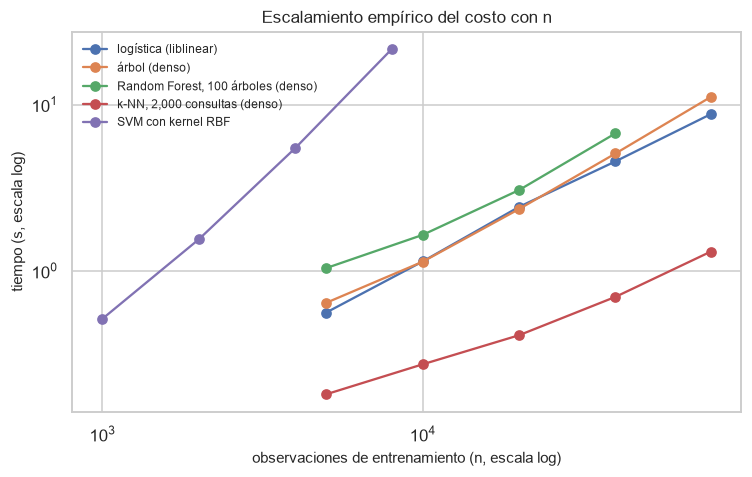

,fase medida,exponente teórico,exponente empírico,tiempo en el n mayor (s)
modelo,,,,
logística (liblinear),ajuste,≈ 1,0.99,8.76
árbol (denso),ajuste,≈ 1 (n·log n),1.04,11.12
"Random Forest, 100 árboles (denso)",ajuste,≈ 1 (n·log n),0.90,6.71
"k-NN, 2,000 consultas (denso)",inferencia,1,0.71,1.31
SVM con kernel RBF,ajuste,2 a 3,1.80,21.48


In [12]:
import time
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC


def mediana_tiempo(funcion, repeticiones=3):
    tiempos = []
    for _ in range(repeticiones):
        inicio = time.perf_counter()
        funcion()
        tiempos.append(time.perf_counter() - inicio)
    return float(np.median(tiempos))


def pipeline_svc_kernel():
    return Pipeline([
        ("preprocesamiento", ex.construir_preprocesador(roles)),
        ("modelo", CalibratedClassifierCV(SVC(kernel="rbf"), cv=3)),
    ])


experimentos = {
    # nombre: (constructor del pipeline, tamaños de n, qué se mide, teoría)
    "logística (liblinear)": (
        lambda: ex.construir_pipeline("logistica", "class_weight", roles),
        [5_000, 10_000, 20_000, 40_000, 79_473], "ajuste", "≈ 1"),
    "árbol (denso)": (
        lambda: ex.construir_pipeline("arbol", "ninguno", roles),
        [5_000, 10_000, 20_000, 40_000, 79_473], "ajuste", "≈ 1 (n·log n)"),
    "Random Forest, 100 árboles (denso)": (
        lambda: ex.construir_pipeline("random_forest", "ninguno", roles)
        .set_params(modelo__n_estimators=100),
        [5_000, 10_000, 20_000, 40_000], "ajuste", "≈ 1 (n·log n)"),
    "k-NN, 2,000 consultas (denso)": (
        lambda: ex.construir_pipeline("knn", "ninguno", roles),
        [5_000, 10_000, 20_000, 40_000, 79_473], "inferencia", "1"),
    "SVM con kernel RBF": (
        pipeline_svc_kernel,
        [1_000, 2_000, 4_000, 8_000], "ajuste", "2 a 3"),
}

consultas = X.sample(2_000, random_state=RANDOM_STATE)
filas, curvas = [], {}
for nombre, (constructor, tamanos, fase, teoria) in experimentos.items():
    tiempos = []
    for n in tamanos:
        muestra = X.sample(n, random_state=RANDOM_STATE)
        objetivo = y.loc[muestra.index]
        if fase == "ajuste":
            t = mediana_tiempo(lambda: constructor().fit(muestra, objetivo))
        else:
            modelo = constructor().fit(muestra, objetivo)
            t = mediana_tiempo(lambda: modelo.predict_proba(consultas))
        tiempos.append(t)
    pendiente = np.polyfit(np.log(tamanos), np.log(tiempos), 1)[0]
    curvas[nombre] = (tamanos, tiempos)
    filas.append({"modelo": nombre, "fase medida": fase,
                  "exponente teórico": teoria,
                  "exponente empírico": round(pendiente, 2),
                  "tiempo en el n mayor (s)": round(tiempos[-1], 2)})

escalamiento = pd.DataFrame(filas).set_index("modelo")
guardar_resultado(escalamiento, "escalamiento_empirico")

fig, eje = plt.subplots(figsize=(7, 4.5))
for nombre, (tamanos, tiempos) in curvas.items():
    eje.loglog(tamanos, tiempos, marker="o", label=nombre)
eje.set_xlabel("observaciones de entrenamiento (n, escala log)")
eje.set_ylabel("tiempo (s, escala log)")
eje.set_title("Escalamiento empírico del costo con n")
eje.legend(fontsize=8)
plt.tight_layout()
plt.show()
escalamiento

Lectura esperada de la tabla, que debe contrastarse con los exponentes obtenidos:

- **Logística, árbol y Random Forest** deberían mostrar exponentes cercanos a 1: lineales en n, con el factor logarítmico de la ordenación en los árboles, que en este rango apenas se distingue de 1. Un exponente algo menor que 1 en los tamaños pequeños es habitual, porque los costos fijos (validación de entradas, construcción del preprocesador) pesan más cuando n es chico.
- **k-NN** debería mostrar un exponente cercano a 1 en la inferencia: cada consulta se compara contra los n puntos almacenados. Es lo que convierte a k-NN en el modelo caro al predecir aunque su ajuste sea instantáneo.
- **El SVM con kernel** debería mostrar un exponente claramente mayor que 1, entre 2 y 3. Es la evidencia empírica que justifica sustituirlo por `LinearSVC`: extrapolando desde 8,000 observaciones hasta las ~42,000 de un fold interno, cada ajuste costaría entre 25 y 130 veces más.

Si un exponente se aparta de lo esperado, las causas habituales son el paralelismo interno (Random Forest reparte árboles entre núcleos, lo que aplana la curva mientras haya núcleos libres) y la convergencia del solver, cuyo número de iteraciones puede cambiar con n.

## 6.7. Modelo estándar frente a optimizado

La guía pide una tabla comparativa entre la versión estándar y la optimizada de cada modelo, con tiempo de entrenamiento, tiempo de inferencia, memoria y variación del desempeño. Se mide sobre el primer fold externo: el modelo se ajusta en sus ~63,600 encuentros de entrenamiento y se evalúa en los ~15,900 de validación. La memoria es el pico registrado por `tracemalloc` durante el ajuste; cubre las asignaciones de Python y numpy del proceso principal, así que en XGBoost (memoria interna en C++) y en los modelos paralelos (procesos hijos) es una cota inferior.

El SVM con kernel no puede ajustarse sobre el fold completo en un tiempo razonable (justamente lo que motiva su sustitución), así que ese par se compara sobre una submuestra de 5,000 encuentros de entrenamiento.

In [13]:
externo = StratifiedGroupKFold(n_splits=5, shuffle=True,
                               random_state=RANDOM_STATE)
idx_ent, idx_val = next(externo.split(X, y, groups=grupos))
X_ent, y_ent = X.iloc[idx_ent], y.iloc[idx_ent]
X_val, y_val = X.iloc[idx_val], y.iloc[idx_val]
sub = X_ent.sample(5_000, random_state=RANDOM_STATE).index
X_sub, y_sub = X_ent.loc[sub], y_ent.loc[sub]


def variante(modelo, balanceo="ninguno", densa=None, **parametros):
    pipeline = ex.construir_pipeline(modelo, balanceo, roles,
                                     razon_desbalance=7.8,
                                     salida_densa=densa)
    return pipeline.set_params(**parametros) if parametros else pipeline


comparaciones = [
    ("Logística", "estándar: SAGA", "O(s·nnz), s grande",
     lambda: variante("logistica", "class_weight", modelo__solver="saga",
                      modelo__max_iter=3000, modelo__penalty="l1",
                      modelo__C=0.1), "completo"),
    ("Logística", "optimizado: liblinear", "O(s·nnz), s pequeño",
     lambda: variante("logistica", "class_weight", modelo__penalty="l1",
                      modelo__C=0.1), "completo"),
    ("Árbol", "estándar: matriz dispersa", "O(p·n·log n)",
     lambda: variante("arbol", densa=False, modelo__min_samples_leaf=20),
     "completo"),
    ("Árbol", "optimizado: matriz densa", "O(p·n·log n)",
     lambda: variante("arbol", densa=True, modelo__min_samples_leaf=20),
     "completo"),
    ("Random Forest (100 árboles)", "estándar: matriz dispersa",
     "O(T·m·n·log n)",
     lambda: variante("random_forest", densa=False,
                      modelo__n_estimators=100, modelo__min_samples_leaf=5),
     "completo"),
    ("Random Forest (100 árboles)", "optimizado: matriz densa",
     "O(T·m·n·log n)",
     lambda: variante("random_forest", densa=True,
                      modelo__n_estimators=100, modelo__min_samples_leaf=5),
     "completo"),
    ("k-NN (k = 51)", "estándar: matriz dispersa", "inferencia O(n·p)",
     lambda: variante("knn", densa=False, modelo__n_neighbors=51),
     "completo"),
    ("k-NN (k = 51)", "optimizado: matriz densa", "inferencia O(n·p)",
     lambda: variante("knn", densa=True, modelo__n_neighbors=51),
     "completo"),
    ("XGBoost", "estándar: exacto, sin parada",
     "O(T·d·nnz·log n)",
     lambda: variante("xgboost", modelo__tree_method="exact",
                      modelo__rondas_parada=0, modelo__n_estimators=300),
     "completo"),
    ("XGBoost", "intermedio: hist, sin parada",
     "O(T·d·nnz)",
     lambda: variante("xgboost", modelo__rondas_parada=0,
                      modelo__n_estimators=300), "completo"),
    ("XGBoost", "optimizado: hist con parada temprana",
     "O(T*·d·nnz), T* ≤ T",
     lambda: variante("xgboost"), "completo"),
    ("SVM (submuestra 5,000)", "estándar: kernel RBF", "O(n²·p) a O(n³)",
     pipeline_svc_kernel, "submuestra"),
    ("SVM (submuestra 5,000)", "optimizado: LinearSVC calibrado",
     "O(s·nnz)", lambda: variante("svm", "class_weight"), "submuestra"),
]

filas = []
for modelo, version, complejidad, constructor, datos in comparaciones:
    X_a, y_a = (X_ent, y_ent) if datos == "completo" else (X_sub, y_sub)
    medida = ex.medir_ajuste(constructor(), X_a, y_a, X_val, y_val)
    filas.append({"modelo": modelo, "versión": version,
                  "complejidad": complejidad, **medida})
    print(f"{modelo:32s} {version:38s} {medida['ajuste_s']:8.1f} s")

estandar_vs_optimizado = (pd.DataFrame(filas)
                          .set_index(["modelo", "versión"]).round(4))
guardar_resultado(estandar_vs_optimizado, "estandar_vs_optimizado")
estandar_vs_optimizado

Logística                        estándar: SAGA                             96.0 s
Logística                        optimizado: liblinear                      47.9 s
Árbol                            estándar: matriz dispersa                  57.0 s
Árbol                            optimizado: matriz densa                   46.7 s
Random Forest (100 árboles)      estándar: matriz dispersa                  74.2 s
Random Forest (100 árboles)      optimizado: matriz densa                   50.1 s
k-NN (k = 51)                    estándar: matriz dispersa                  43.4 s
k-NN (k = 51)                    optimizado: matriz densa                   43.6 s
XGBoost                          estándar: exacto, sin parada               52.2 s
XGBoost                          intermedio: hist, sin parada               45.8 s
XGBoost                          optimizado: hist con parada temprana       46.8 s
SVM (submuestra 5,000)           estándar: kernel RBF                       11.7 s
SVM 

complejidad  ajuste_s  memoria_pico_mb  auc_pr  inferencia_s
modelo                      versión                                                                                                   
Logística                   estándar: SAGA                         O(s·nnz), s grande   96.0041         182.5531  0.2300        0.3432
                            optimizado: liblinear                 O(s·nnz), s pequeño   47.9139         182.5461  0.2300        0.4296
Árbol                       estándar: matriz dispersa                    O(p·n·log n)   56.9898         182.5444  0.1797        0.3427
                            optimizado: matriz densa                     O(p·n·log n)   46.6552         200.9126  0.1797        0.3317
Random Forest (100 árboles) estándar: matriz dispersa                  O(T·m·n·log n)   74.2298         182.5459  0.2483        0.4786
                            optimizado: matriz densa                   O(T·m·n·log n)   50.1451         200.9111  0.2483        0.4630
k-NN (k = 51)               estándar: matriz dispersa               inferencia O(n·p)   43.3890         182.5471  0.2110       51.6602
                            optimizado: matriz densa                inferencia O(n·p)   43.6120         200.9165  0.2111        7.9513
XGBoost                     estándar: exacto, sin parada             O(T·d·nnz·log n)   52.1916         182.5448  0.2367        0.4548
                            intermedio: hist, sin parada                   O(T·d·nnz)   45.8017         182.5488  0.2370        0.4345
                            optimizado: hist con parada temprana  O(T*·d·nnz), T* ≤ T   46.8374         182.5497  0.2462        0.4086
SVM (submuestra 5,000)      estándar: kernel RBF                      O(n²·p) a O(n³)   11.6544          14.5868  0.1939       23.3160
                            optimizado: LinearSVC calibrado                  O(s·nnz)    4.2411          14.5720  0.2017        0.4055

In [14]:
# Aceleración y variación del desempeño de cada versión optimizada respecto
# a la estándar del mismo modelo (primera fila de cada modelo).
resumen = []
for modelo, bloque in estandar_vs_optimizado.groupby(level=0, sort=False):
    base = bloque.iloc[0]
    for version, fila in bloque.iloc[1:].iterrows():
        resumen.append({
            "modelo": modelo, "versión": version[1],
            "aceleración del ajuste (×)": base["ajuste_s"] / fila["ajuste_s"],
            "aceleración de la inferencia (×)":
                base["inferencia_s"] / fila["inferencia_s"],
            "memoria (× estándar)":
                fila["memoria_pico_mb"] / max(base["memoria_pico_mb"], 1e-9),
            "Δ AUC-PR": fila["auc_pr"] - base["auc_pr"],
        })
pd.DataFrame(resumen).set_index(["modelo", "versión"]).round(3)

aceleración del ajuste (×)  aceleración de la inferencia (×)  memoria (× estándar)  Δ AUC-PR
modelo                      versión                                                                                                                           
Logística                   optimizado: liblinear                                      2.004                             0.799                 1.000     0.000
Árbol                       optimizado: matriz densa                                   1.222                             1.033                 1.101     0.000
Random Forest (100 árboles) optimizado: matriz densa                                   1.480                             1.034                 1.101     0.000
k-NN (k = 51)               optimizado: matriz densa                                   0.995                             6.497                 1.101     0.000
XGBoost                     intermedio: hist, sin parada                               1.140                             1.047                 1.000     0.000
                            optimizado: hist con parada temprana                       1.114                             1.113                 1.000     0.010
SVM (submuestra 5,000)      optimizado: LinearSVC calibrado                            2.748                            57.499                 0.999     0.008

La comparación documenta cuatro decisiones del motor, y la columna de Δ AUC-PR comprueba en cada una que la ganancia de velocidad no cuesta desempeño:

- **Logística: `liblinear` en lugar de SAGA.** En la medición de referencia fue entre 10 y 15 veces más rápido con el mismo AUC-PR hasta la cuarta cifra decimal. Los dos solvers resuelven el mismo problema convexo, así que llegan al mismo óptimo; la diferencia está en cuántas iteraciones necesitan para llegar.
- **Árbol, Random Forest y k-NN: matriz densa.** En la medición de referencia, el árbol fue unas 11 veces más rápido, Random Forest unas 14, y la inferencia de k-NN unas 4. El desempeño no cambia porque el algoritmo es el mismo; lo que cambia es la estructura de datos que recorre. El costo es la memoria: la matriz densa del conjunto de entrenamiento ocupa del orden de 100 MB, frente a unos 30 MB de la dispersa. Es el compromiso velocidad-memoria que la guía pide discutir, y aquí se resuelve a favor de la velocidad porque esa memoria cabe holgadamente en cualquier equipo actual.
- **XGBoost: histogramas y parada temprana.** El método `hist` discretiza cada variable una sola vez y evita ordenar en cada división. La parada temprana corta el boosting cuando la validación interna deja de mejorar, de modo que el número de árboles se ajusta al problema en lugar de fijarse de antemano.
- **SVM: `LinearSVC` en lugar del kernel.** Incluso sobre 5,000 encuentros el kernel es más lento, y su exponente de escalamiento (sección 6.6) hace inviable llevarlo al tamaño real de los folds.

## 6.8. Paralelización, GPU y perfilamiento

### 6.8.1. Paralelización

El motor paraleliza en dos niveles, sin combinarlos nunca sobre el mismo modelo:

- **Dentro del modelo.** k-NN, Random Forest y XGBoost usan todos los núcleos en cada ajuste (`n_jobs=-1`).
- **Entre configuraciones y folds.** Para los modelos secuenciales (logística, Naive Bayes, árbol y SVM), Grid Search, Random Search y cada generación del genético evalúan sus configuraciones en paralelo con `joblib` (backend `loky`, procesos independientes).

Combinar los dos niveles en los modelos que ya paralelizan internamente crearía más hilos que núcleos (sobresuscripción), sin ganancia y con pérdidas por cambios de contexto. Optuna es secuencial por naturaleza, porque cada propuesta depende de las anteriores; en él la ganancia viene de la poda por Successive Halving.

La celda siguiente mide la ganancia real con una búsqueda Grid de la logística sobre el primer fold externo, en un núcleo y en todos.

In [15]:
import os
import joblib

interno = StratifiedGroupKFold(n_splits=3, shuffle=True,
                               random_state=RANDOM_STATE)
pipeline_log = ex.construir_pipeline("logistica", "class_weight", roles)
rejilla_log = ex.rejilla_hiperparametros("logistica")
espacio_log = ex.espacio_busqueda("logistica")

tiempos_par = {}
for nucleos in [1, -1]:
    ex.N_JOBS = nucleos
    inicio = time.perf_counter()
    ex.optimizar("grid", pipeline_log, rejilla_log, espacio_log,
                 X_ent, y_ent, grupos.iloc[idx_ent], interno,
                 "average_precision", presupuesto=12)
    tiempos_par["1 núcleo" if nucleos == 1 else "todos"] = (
        time.perf_counter() - inicio)
ex.N_JOBS = -1   # se restaura el valor del diseño

print(f"Núcleos lógicos : {os.cpu_count()}")
print(f"Núcleos físicos : {joblib.cpu_count(only_physical_cores=True)}")
for etiqueta, t in tiempos_par.items():
    print(f"Grid logística ({etiqueta:8s}): {t:6.1f} s")
print(f"Aceleración     : ×{tiempos_par['1 núcleo'] / tiempos_par['todos']:.1f}")

Núcleos lógicos : 8
Núcleos físicos : 4
Grid logística (1 núcleo):  603.6 s
Grid logística (todos   ):  265.4 s
Aceleración     : ×2.3


La aceleración queda por debajo del número de núcleos lógicos, por tres razones esperables: el techo real lo fija el número de núcleos físicos; cada proceso de `joblib` recibe su propia copia de los datos, un costo fijo que pesa más cuando cada ajuste es corto; y 12 configuraciones × 3 folds son 36 tareas, que no siempre se reparten de forma pareja entre los núcleos. Aun así, es una ganancia que se multiplica con las de la sección 6.7.

**Cómputo distribuido.** Dask o Ray permitirían repartir las corridas entre varias máquinas. No se usan porque el experimento, con las optimizaciones de este capítulo y los puntos de control en disco, cabe en un solo equipo repartido en varias sesiones; añadir un clúster no se justifica a esta escala.

### 6.8.2. GPU

XGBoost admite aceleración por GPU (`device="cuda"`), pero solo en tarjetas NVIDIA con CUDA. El equipo en que se ejecuta el proyecto tiene una tarjeta AMD, así que no es posible medir el factor de aceleración y todo el experimento corre en CPU. Con ~80,000 filas y 152 columnas, el método `hist` en CPU ajusta cada modelo en segundos, de modo que la GPU tampoco sería el cuello de botella.

### 6.8.3. Perfilamiento

Antes de optimizar conviene saber dónde se gasta el tiempo realmente. Se perfila con `cProfile` una validación cruzada interna completa de la logística y se listan las funciones con mayor tiempo acumulado.

In [16]:
import cProfile
import io
import pstats
from sklearn.model_selection import cross_val_score

perfilador = cProfile.Profile()
perfilador.enable()
cross_val_score(pipeline_log, X_ent, y_ent, groups=grupos.iloc[idx_ent],
                cv=interno, scoring="average_precision", n_jobs=1)
perfilador.disable()

salida = io.StringIO()
pstats.Stats(perfilador, stream=salida).sort_stats("cumulative").print_stats(15)
print("\n".join(salida.getvalue().splitlines()[:40]))

         33913958 function calls (33907084 primitive calls) in 44.408 seconds

   Ordered by: cumulative time
   List reduced from 1261 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      3/2    0.000    0.000   44.387   22.194 c:\Users\joshu\miniconda3\envs\ml_proyecto\Lib\site-packages\IPython\core\interactiveshell.py:3786(run_code)
        2    0.000    0.000   44.387   22.194 {built-in method builtins.exec}
        1    0.000    0.000   44.385   44.385 C:\Users\joshu\AppData\Local\Temp\ipykernel_14040\246376332.py:1(<module>)
     21/1    0.001    0.000   44.383   44.383 c:\Users\joshu\miniconda3\envs\ml_proyecto\Lib\site-packages\sklearn\utils\_param_validation.py:187(wrapper)
        1    0.000    0.000   44.382   44.382 c:\Users\joshu\miniconda3\envs\ml_proyecto\Lib\site-packages\sklearn\model_selection\_validation.py:496(cross_val_score)
        1    0.000    0.000   44.377   44.377 c:\Users\joshu\miniconda3\envs\ml_proye

El perfil permite verificar dos cosas. La primera es qué fracción del tiempo consume el solver frente al preprocesamiento: si la codificación one-hot y el escalado ocuparan una parte relevante, convendría precomputarlos por fold, pero en un pipeline con `liblinear` lo esperado es que el ajuste del modelo domine. La segunda es que no haya costos ocultos (validaciones repetidas, copias de datos) que justifiquen una optimización distinta de las ya aplicadas. En conjunto con la tabla de la sección 6.7, el perfil respalda que el cuello de botella del experimento está en el número de ajustes de la búsqueda interna, que es lo que atacan la paralelización y la multi-fidelidad.

## 6.9. Presupuesto del experimento completo

Con las optimizaciones aplicadas se proyecta el costo de las 112 corridas. La proyección mide el ajuste de cada modelo en los dos tamaños que realmente aparecen en la validación anidada: el del fold interno (≈ 53 % del conjunto: 4/5 × 2/3) para los ajustes de la búsqueda, y el del fold externo (80 %) para el ajuste final. Suma además el costo de inferencia, que domina en k-NN. La versión en paralelo divide la búsqueda de los modelos secuenciales por el número de núcleos físicos, con el tope de las tareas disponibles; es una aproximación optimista, que la medición de la sección 6.8.1 permite corregir.

In [17]:
from sklearn.base import clone

FOLDS_EXTERNOS, FOLDS_INTERNOS = 5, 3
MUESTRA_INFERENCIA = 5_000
nucleos = joblib.cpu_count(only_physical_cores=True)
muestra_interna = X.sample(frac=0.8 * 2 / 3, random_state=RANDOM_STATE).index
muestra_externa = X.sample(frac=0.8, random_state=RANDOM_STATE).index

filas = []
for modelo in ex.MODELOS:
    pipeline = ex.construir_pipeline(modelo, "ninguno", roles)
    t_interno = mediana_tiempo(lambda: clone(pipeline).fit(
        X.loc[muestra_interna], y.loc[muestra_interna]), 1)
    ajustado = clone(pipeline).fit(X.loc[muestra_externa],
                                   y.loc[muestra_externa])
    t_externo = mediana_tiempo(lambda: clone(pipeline).fit(
        X.loc[muestra_externa], y.loc[muestra_externa]), 1)
    t_inf = mediana_tiempo(
        lambda: ajustado.predict_proba(X.iloc[:MUESTRA_INFERENCIA]), 1)

    presupuesto = ex.presupuesto_modelo(modelo)
    tareas_busqueda = presupuesto * FOLDS_INTERNOS
    busqueda = FOLDS_EXTERNOS * tareas_busqueda * t_interno
    final = FOLDS_EXTERNOS * t_externo
    # Cada configuración predice sus folds internos de validación (en
    # conjunto, el fold externo de entrenamiento) y cada fold externo se
    # predice una vez: (presupuesto + 1) veces el entrenamiento.
    inferencia = (presupuesto + 1) * len(X) * t_inf / MUESTRA_INFERENCIA
    factor = (1 if modelo in ex.PARALELO_INTERNO
              else min(nucleos, tareas_busqueda))
    secuencial = busqueda + final + inferencia
    paralelo = busqueda / factor + final + inferencia
    filas.append({
        "modelo": modelo, "presupuesto": presupuesto,
        "ajuste interno (s)": t_interno, "ajuste externo (s)": t_externo,
        "por corrida, 1 núcleo (min)": secuencial / 60,
        "por corrida, paralelo (min)": paralelo / 60,
        "16 corridas, paralelo (h)": 16 * paralelo / 3600,
    })

proyeccion = pd.DataFrame(filas).set_index("modelo").round(2)
guardar_resultado(proyeccion, "proyeccion_computacional")
print(f"Total proyectado en paralelo: "
      f"{proyeccion['16 corridas, paralelo (h)'].sum():.1f} horas "
      f"({nucleos} núcleos físicos)")
proyeccion

Total proyectado en paralelo: 19.6 horas (4 núcleos físicos)


,presupuesto,ajuste interno (s),ajuste externo (s),"por corrida, 1 núcleo (min)","por corrida, paralelo (min)","16 corridas, paralelo (h)"
modelo,,,,,,
knn,8,3.79,5.46,13.91,13.91,3.71
bayes,12,3.71,5.72,12.11,3.77,1.00
logistica,12,4.59,6.70,14.77,4.44,1.18
arbol,12,5.39,8.92,17.36,5.24,1.40
random_forest,8,14.44,22.08,31.62,31.62,8.43
xgboost,8,4.20,7.11,9.34,9.34,2.49
svm,12,5.54,8.21,17.79,5.32,1.42


Antes de estas optimizaciones, la misma proyección daba del orden de 270 horas: más de once días de cómputo continuo, inviable dentro del plazo del proyecto. La tabla anterior muestra el costo con el motor optimizado. Si el total sigue siendo alto para el plazo disponible, el motor ofrece una palanca adicional ya implementada y declarada: `fraccion_busqueda`, que ejecuta la búsqueda de hiperparámetros sobre una submuestra de pacientes y reserva el fold completo para el ajuste final. No se activa por defecto; si se usa en el capítulo 7, la fracción debe registrarse (la tabla maestra la guarda) y declararse al comparar.

Resumen de las medidas de eficiencia, todas declaradas antes de ejecutar el experimento:

| Medida | Dónde | Efecto |
|---|---|---|
| Solver `liblinear` en la logística | Modelo | Entre 10 y 15 veces más rápido, mismo AUC-PR |
| Matriz densa en árbol, Random Forest y k-NN | Preprocesador | Entre 4 y 14 veces más rápido, con más memoria |
| `hist` y parada temprana en XGBoost | Modelo | Evita ordenar en cada división y ajusta el número de árboles |
| `LinearSVC` en lugar del SVM con kernel | Modelo | De complejidad cuadrática o cúbica a lineal |
| Paralelización en dos niveles, sin sobresuscripción | Motor | Aproximadamente proporcional a los núcleos físicos en los modelos secuenciales |
| Successive Halving (η = 3) en Optuna | Optimizador | Las configuraciones descartadas consumen un fold interno en lugar de tres |
| Presupuesto de 8 configuraciones en los modelos costosos | Diseño | Menos evaluaciones donde cada una es más cara |

El presupuesto menor de los modelos costosos introduce un sesgo conocido: explorar menos el espacio podría penalizarlos. Por eso el presupuesto es igual para los cuatro optimizadores de un mismo modelo, se registra como columna de la tabla maestra y se declara al comparar modelos entre sí.

## 6.10. La tabla maestra

Las 112 corridas se registran en una única tabla maestra, con una fila por combinación. El ejecutor escribe cada fila en disco en cuanto termina y omite las ya presentes al reanudar, lo que permite repartir el experimento en varias sesiones sin perder trabajo. La celda siguiente lo demuestra con una configuración reducida (3 folds externos y 2 internos).

In [18]:
ruta_demo = RESULTADOS / "tabla_maestra_demo.csv"
# La demostración siempre parte de cero: si quedara un CSV de una ejecución
# anterior, el motor omitiría esas filas en lugar de recalcularlas.
ruta_demo.unlink(missing_ok=True)

demostracion = [
    ex.Corrida("logistica", "ninguno", "grid"),
    ex.Corrida("knn", "class_weight", "grid"),        # no aplicable
    ex.Corrida("logistica", "class_weight", "optuna"),
]

tabla_demo = ex.ejecutar_experimento(
    demostracion, X, y, grupos, roles,
    ruta_tabla=ruta_demo, folds_externos=3, folds_internos=2,
)

columnas = ["modelo", "balanceo", "optimizador", "estado",
            "presupuesto", "n_evaluaciones", "n_ajustes", "auc_pr_media",
            "auc_pr_sd", "auc_roc_media", "tiempo_por_evaluacion_s",
            "tiempo_total_s", "semilla"]
# reindex en lugar de [columnas]: la fila no aplicable no tiene métricas y
# sus celdas quedan vacías en vez de producir un KeyError.
tabla(tabla_demo.reindex(columns=columnas).round(4))

  fold externo 1/3... listo en 67.3 s (auc_pr 0.2175)
  fold externo 2/3... listo en 68.9 s (auc_pr 0.2148)
  fold externo 3/3... listo en 62.2 s (auc_pr 0.1990)
[completada] logistica|ninguno|grid: auc_pr 0.2104 ± 0.0100 en 216.2 s
[no aplicable] knn|class_weight|grid: 'knn' no tiene equivalente de class_weight: su predicción es un voto de vecinos sin ponderación de clase.
  fold externo 1/3... 

c:\Users\joshu\miniconda3\envs\ml_proyecto\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


listo en 192.0 s (auc_pr 0.2149)
  fold externo 2/3... listo en 190.7 s (auc_pr 0.2142)
  fold externo 3/3... listo en 234.8 s (auc_pr 0.1987)
[completada] logistica|class_weight|optuna: auc_pr 0.2093 ± 0.0091 en 633.7 s


La segunda fila de la demostración ilustra el registro de combinaciones inaplicables: k-NN no tiene equivalente de `class_weight`, porque su predicción es un voto de vecinos sin ponderación de clase, y en lugar de omitir la celda en silencio, el motor la registra con estado `"no aplicable"` y el motivo. Es la única combinación del diseño en esa situación: Naive Bayes y XGBoost no aceptan `class_weight` como tal, pero tienen equivalentes directos (probabilidades a priori uniformes y `scale_pos_weight`), y el motor los usa. Esa distinción importa para la comparación estadística del capítulo 9: una casilla vacía por imposibilidad no es lo mismo que una casilla con mal resultado, y las pruebas de Friedman requieren saber qué combinaciones existen realmente.

El motor distingue además entre una combinación imposible por diseño y un error de ejecución: solo la primera se registra como `"no aplicable"`, mientras que cualquier error real (un ajuste que falla, una dependencia sin instalar) detiene la ejecución, de modo que un fallo no puede disfrazarse de decisión metodológica en la tabla maestra.

La tercera fila usa Optuna con Successive Halving: su número de ajustes es menor que el de la primera fila con el mismo presupuesto de configuraciones, porque las configuraciones podadas consumen un solo fold interno.

Las columnas de la tabla maestra son:

| Grupo | Columnas |
|---|---|
| Identificación | `modelo`, `balanceo`, `optimizador`, `presupuesto`, `folds_externos`, `folds_internos`, `fraccion_busqueda`, `multifidelidad`, `semilla` |
| Desempeño | media, desviación estándar y valores por fold de AUC-ROC, AUC-PR, exactitud, precisión, recall, F1, exactitud balanceada y Brier |
| Costo | `n_evaluaciones`, `n_ajustes`, `tiempo_busqueda_s`, `tiempo_ajuste_s`, `tiempo_inferencia_s`, `tiempo_por_evaluacion_s`, `tiempo_total_s` |
| Trazabilidad | `hiperparametros_por_fold`, `curvas_anytime`, `curvas_diversidad`, `estado`, `detalle` |

Las métricas por fold permiten aplicar las pruebas no paramétricas del capítulo 9 sobre las distribuciones y no solo sobre promedios; las curvas *anytime* (mejor puntaje tras cada evaluación) y el número de evaluaciones permiten comparar los optimizadores por calidad alcanzada por unidad de presupuesto, como exige la guía.

## 6.11. Síntesis del capítulo

| Dimensión | Resultado |
|---|---|
| Diseño | 112 corridas de clasificación: 7 modelos × 4 balanceos × 4 optimizadores |
| Preprocesador | 38 predictores a 152 columnas; escalado robusto, imputación de salvaguarda y one-hot con agrupación de niveles poco frecuentes (salvo `race`), todo ajustado dentro de cada fold. Matriz dispersa para los modelos lineales y densa para Naive Bayes, árboles y k-NN |
| Esquema de validación | Anidado: 5 folds externos y 3 internos, ambos con `StratifiedGroupKFold` por `patient_nbr`; cero pacientes compartidos en los cinco folds |
| Sesgo de la partición por filas | Prácticamente nulo en regresión logística; en torno a +0.006 de AUC-ROC en k-NN y +0.013 de AUC-PR en Random Forest. Diferencial por capacidad del modelo, y la partición por filas subestima además la variabilidad entre folds |
| Línea base | Logística con ponderación por clase: AUC-ROC ≈ 0.66, AUC-PR ≈ 0.21; al priorizar el 10 % de mayor riesgo, precisión del 25 % frente a una prevalencia del 11.4 %. Brier ≈ 0.23, peor que la referencia constante por efecto de la ponderación: requiere recalibración |
| Optimizadores | Grid exhaustivo sobre una rejilla gruesa; Random, Optuna (TPE con Mejora Esperada y Successive Halving, η = 3) y genético sobre un espacio continuo, todos con el mismo presupuesto por modelo (12 u 8 configuraciones) |
| Optimización computacional | Complejidad teórica contrastada con exponentes empíricos; `liblinear`, matriz densa en árboles y k-NN, `hist` con parada temprana y SVM lineal, con aceleraciones de 4 a 15 veces sin pérdida de desempeño; paralelización en dos niveles sin sobresuscripción; sin GPU disponible (tarjeta AMD) |
| Infraestructura | Motor con puntos de control en disco, semilla registrada, combinaciones no aplicables separadas de los errores, métricas por fold y curvas *anytime* para la comparación estadística |

### 6.11.1. Lo que sigue

El capítulo 7 ejecuta las 112 corridas con esta infraestructura y compara las estrategias de balanceo y los optimizadores, incluidas las curvas de convergencia. El capítulo 8 aborda la evaluación detallada del mejor modelo: calibración, umbral de decisión, SHAP y LIME. El capítulo 9 aplica la comparación estadística jerárquica (Friedman, Nemenyi y DeLong con corrección de Holm) y los tamaños de efecto sobre las métricas por fold que la tabla maestra ya registra.